# Test Plotting

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.data_loading import ECData
from redoxed.plots.eis_plot import NyquistPlot, BodePlot

from redoxed import config
config.set_latex_mode(False) # warning, slows plotting if True. Used to achieve consistent serif fonts by rendering latex. 

%matplotlib inline
# %matplotlib qt

# if think is slowing down, disable autoreload by restarting kernel without it.
%load_ext autoreload
%autoreload 2 

# Get tab10 colors and names (sadly not colorblind friendly)
cmap = plt.get_cmap('tab10')
tab10_names = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan"]
tab10_colors = cmap.colors
# Create a name-to-color dictionary
colour_dict = dict(zip(tab10_names, tab10_colors))
colour_dict["black"] = (0, 0, 0) # add black color

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## View Colours

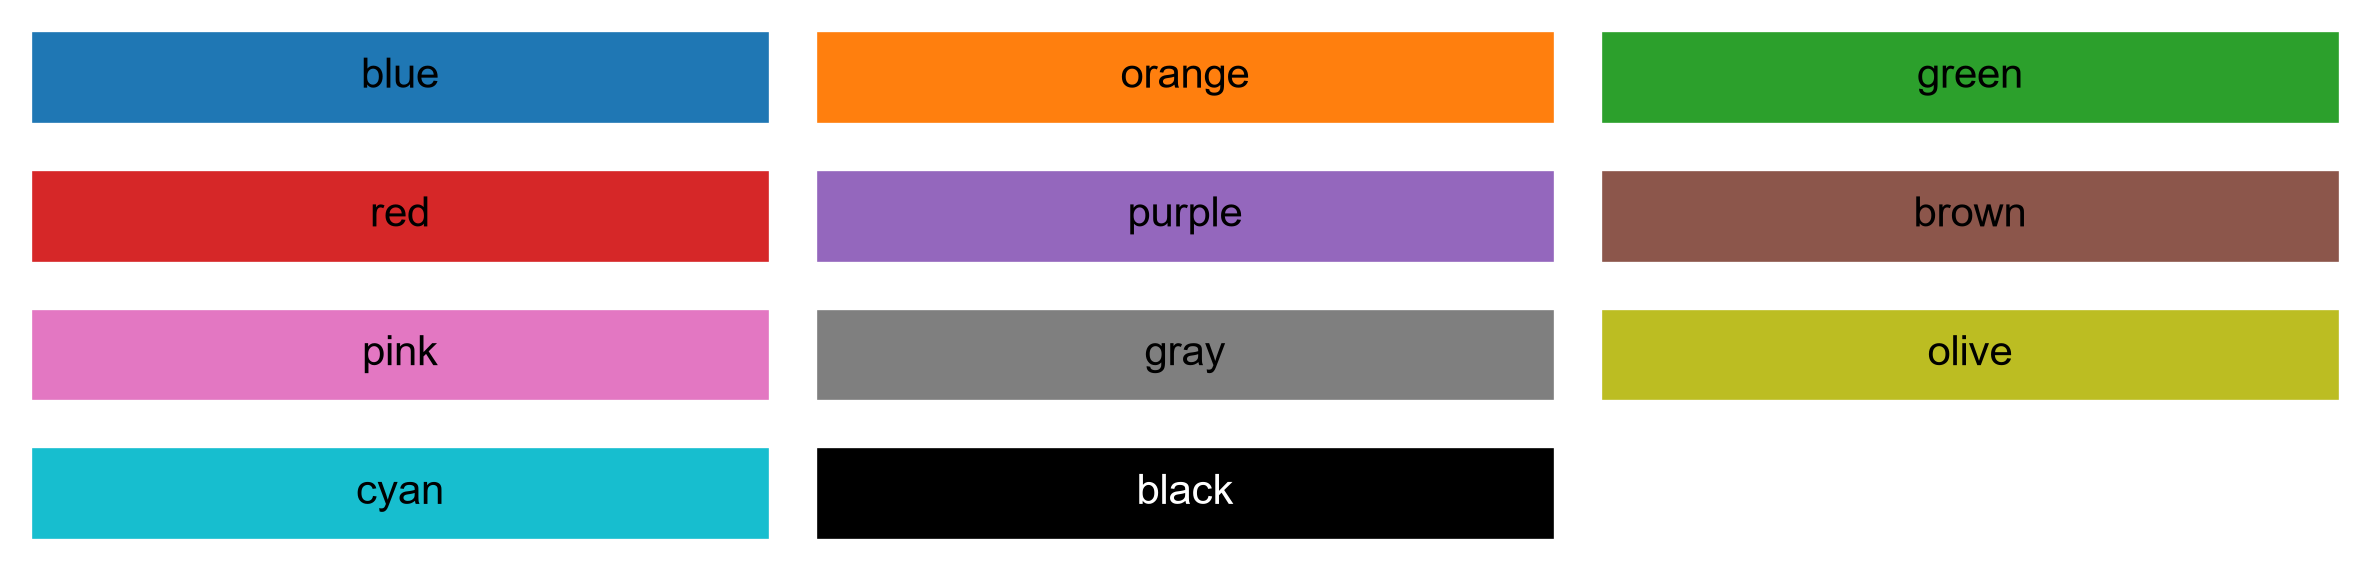

In [16]:
# Create figure with subplots
n_colors = len(colour_dict)
n_cols = 3
n_rows = int(np.ceil(n_colors / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, n_rows * 0.5))
axes = axes.flatten()

for idx, (name, color) in enumerate(colour_dict.items()):
    axes[idx].add_patch(plt.Rectangle((0, 0), 1, 1, facecolor=color))
    axes[idx].text(0.5, 0.5, name, ha='center', va='center', 
                   fontsize=10, color='white' if name == 'black' else 'black')
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(0, 1)
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_colors, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Test plotting EIS

### Multi-cycle dataset

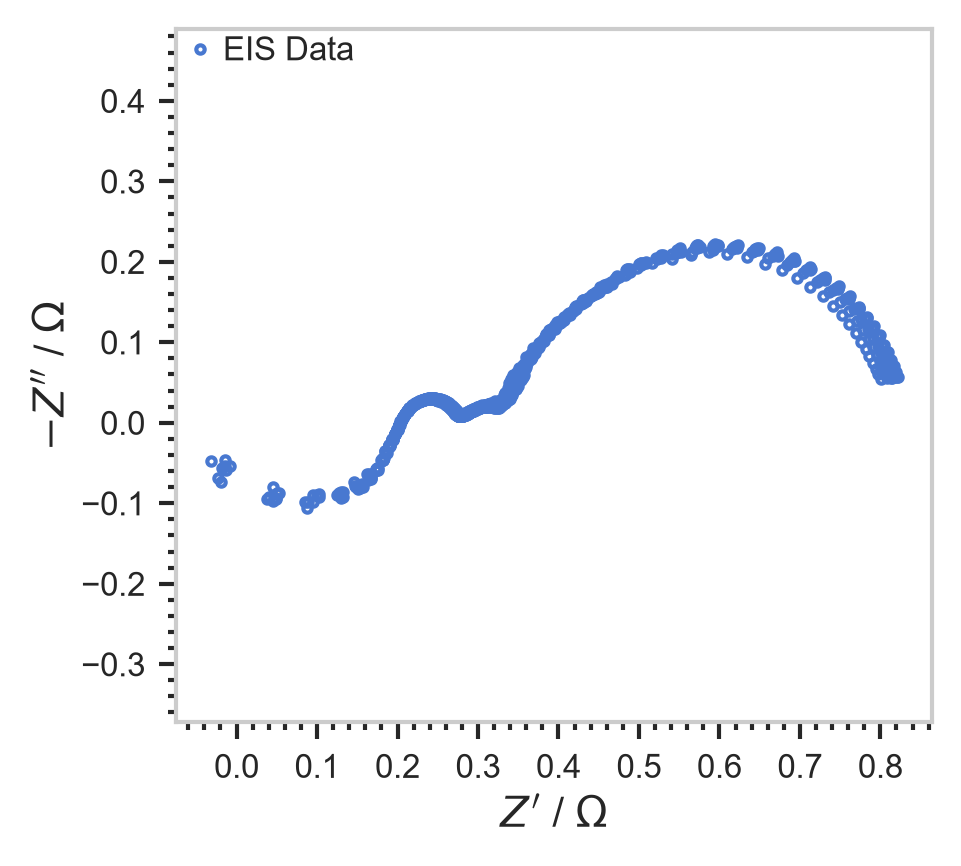

In [17]:
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.21 FB1_FCN_KCl_E620K_GFDB0_B3lasercen\5_50ml_50soc_20mM_FCN_33rpm_laseredge_6Nm_C02.mpr"

ECData_object = BiologicLoader().load_data(fpath=fpath)
# ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=300) 
data_plot.add_plot(EISData_object, label = "EIS Data", linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten. So will padding of labels I think.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y. but can set x and y lim
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # can always edit afterwards like most settings with something like
## Embellishments
data_plot.add_major_ticks(spacing_x = 0.1, spacing_y = 0.1)
data_plot.add_minor_ticks(number_x=5, number_y=5)
# data_plot.ax.grid(True)
# data_plot.ax.legend(bbox_to_anchor=(0., 0.9), loc="upper left") # manual legend settings
data_plot.ax.legend()

display(data_plot.fig)


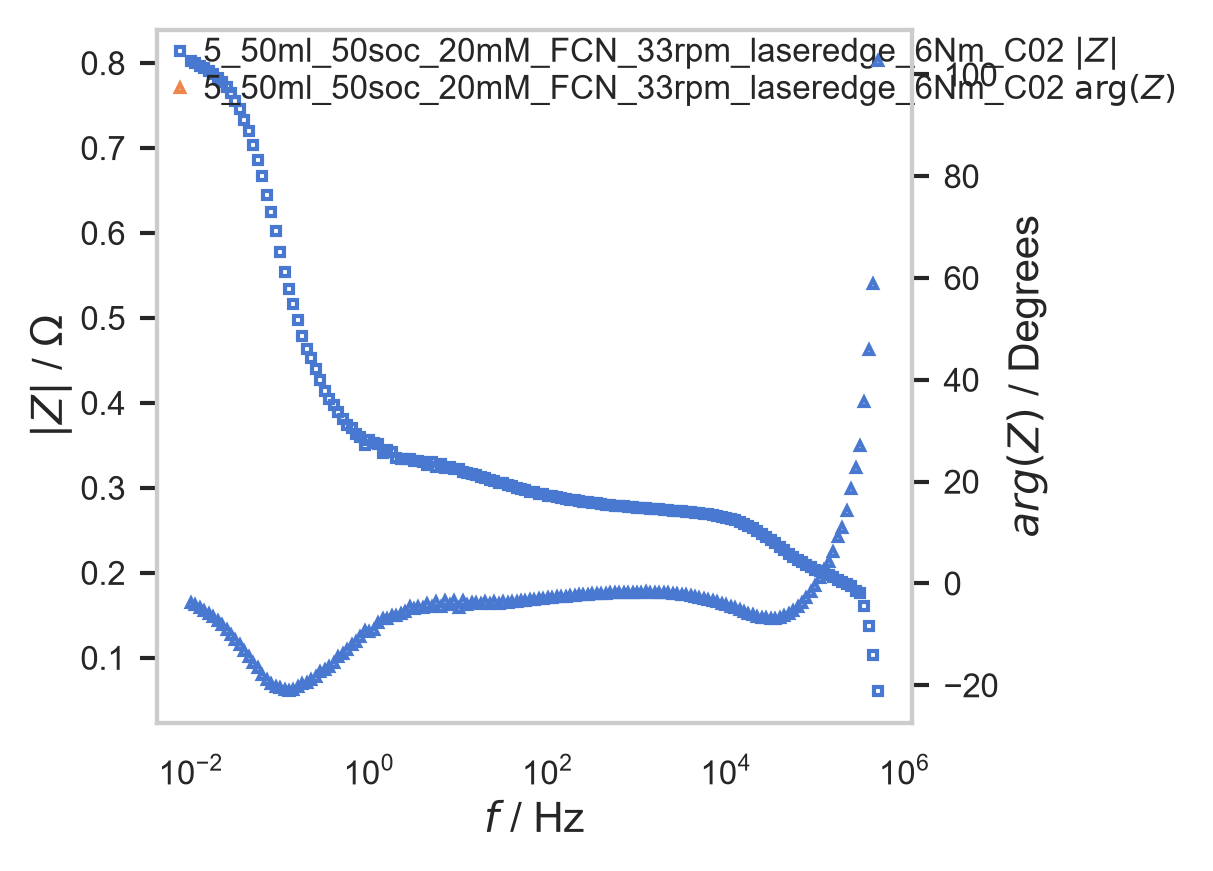

In [18]:
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.21 FB1_FCN_KCl_E620K_GFDB0_B3lasercen\5_50ml_50soc_20mM_FCN_33rpm_laseredge_6Nm_C02.mpr"

ECData_object = BiologicLoader().load_data(fpath=fpath)
ECData_object.df = ECData_object.filter_by_col("cycle number", lambda value: value == 1)
EISData_object = ECData_object.to_EISData()

data_plot = BodePlot(figsize=(3.25, 3), dpi=300) 


data_plot.add_plot(EISData_object, label = EISData_object.label, markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y, but can set x and y lim.
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # Use invisible points if not achieving desired ax limits
## Embellishments
# data_plot.add_major_ticks(spacing_y = 0.1)
# data_plot.add_minor_ticks(number_y = 5)
# data_plot.ax.grid(True)
# data_plot.ax.legend()
data_plot.ax.legend(ncols = 1, bbox_to_anchor=(0., 1), loc="upper left", fontsize = 8) # manual legend settings


display(data_plot.fig)

### Filter cycles + Multiple plots

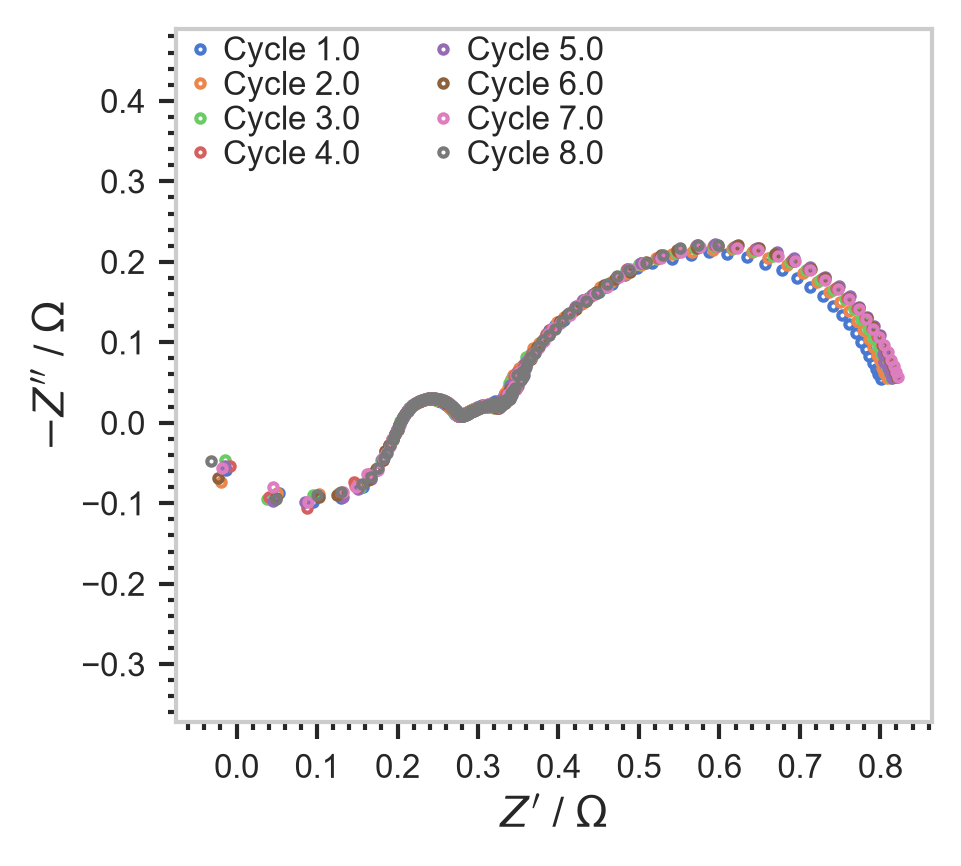

In [19]:
fpath = r"C:\Users\es758\OneDrive - University of Cambridge\PhD\Results\Electrochemistry\Full Cell 3\2025.03.21 FB1_FCN_KCl_E620K_GFDB0_B3lasercen\5_50ml_50soc_20mM_FCN_33rpm_laseredge_6Nm_C02.mpr"

ECData_object = BiologicLoader().load_data(fpath=fpath)

EISData_object_array = []
for cycle in ECData_object.df["cycle number"].unique():
    EISData_object = ECData(df = ECData_object.filter_by_col("cycle number", lambda value: value == cycle), label = f"Cycle {cycle}").to_EISData()
    EISData_object_array.append(EISData_object)

data_plot = NyquistPlot(figsize=(3.25, 3), dpi=300) 

for EISData_object in EISData_object_array:
    data_plot.add_plot(EISData_object, label = EISData_object.label, linestyle = "", marker = "o", markersize = 2)

### Plot formatting
## Ensure ratio equal
# data_plot.ax.set_aspect("equal", adjustable="datalim")  # if enable, overall fig size will be strictly enforced, but x and y limits will be overwritten.
# data_plot.ax.set_aspect('equal',adjustable='box') # if enable this, fig size will get overwritten, at least in y, but can set x and y lim.
## Cropping
# data_plot.ax.set_ylim([0.01, None]) # Use invisible points if not achieving desired ax limits
## Embellishments
data_plot.add_major_ticks(spacing_x = 0.1, spacing_y = 0.1)
data_plot.add_minor_ticks(number_x=5, number_y=5)
# data_plot.ax.grid(True)
data_plot.ax.legend()
data_plot.ax.legend(ncols = 2, bbox_to_anchor=(0., 1), loc="upper left", fontsize = 8) # manual legend settings


display(data_plot.fig)

